In [117]:
import os
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.features import geometry_mask
from shapely.geometry import box
import matplotlib.pyplot as plt

In [118]:
# ================== User Settings ==================
INPUT_FOLDER = r"/Users/ks/Desktop/Wu/Testing"   # same root folder used in Notebook 1
SHAPEFILE_ROOT = r"Grids"
COUNTY_NAME = "Sacramento"                          # matches shapefiles/Sacramento/Sacramento.shp

GRID_ID_FIELD = "GRID_ID"          # unique ID field in your grid shapefile
COVERAGE_THRESHOLD = 0.50        # >50% of a grid cell must have valid data to count as "covered"

# Output goes inside the input folder itself
OUTPUT_DIR = os.path.join(INPUT_FOLDER, "01_Grid_Coverage")
os.makedirs(OUTPUT_DIR, exist_ok=True)
SUMMARY_CSV = os.path.join(OUTPUT_DIR, "grid_coverage_summary.csv")

In [119]:
shapefile_path = os.path.join(SHAPEFILE_ROOT, COUNTY_NAME, f"Sac_grid.shp")

if not os.path.isfile(shapefile_path):
    raise FileNotFoundError(f"Shapefile not found: {shapefile_path}")

grid_gdf = gpd.read_file(shapefile_path)
print(f"Loaded {len(grid_gdf)} grid cells from {shapefile_path}")

Loaded 4255 grid cells from Grids/Sacramento/Sac_grid.shp


In [120]:
def compute_grid_coverage(grid_orig, raster_path, threshold=0.5, grid_id_field="GRID_ID"):
    """
    For a single tiff, compute the fraction of valid (non-nodata) pixels
    inside each grid cell. A cell is 'covered' if that fraction > threshold.

    Returns a GeoDataFrame copy of grid_orig with added columns:
      - valid_fraction : fraction of the cell's pixels that are valid
      - covered        : bool, True if valid_fraction > threshold
    """
    grid = grid_orig.reset_index(drop=True).copy()

    with rasterio.open(raster_path) as src:
        grid_work = grid.to_crs(src.crs)
        raster_extent = box(*src.bounds)

        valid_frac = np.zeros(len(grid_work), dtype="float32")

        for i, row in grid_work.iterrows():
            geom = row.geometry
            if not geom.intersects(raster_extent):
                continue

            geom_clip = geom.intersection(raster_extent)
            if geom_clip.is_empty:
                continue

            try:
                out_img, out_transform = rio_mask(
                    src, [geom_clip], crop=True, filled=True, nodata=np.nan
                )
            except ValueError:
                continue

            data = out_img[0]
            inside_mask = geometry_mask(
                [geom_clip],
                out_shape=data.shape,
                transform=out_transform,
                all_touched=False,
                invert=True,
            )

            n_total = int(inside_mask.sum())
            if n_total == 0:
                continue

            data_inside = np.where(inside_mask, data, np.nan)
            n_valid = int(np.isfinite(data_inside).sum())

            valid_frac[i] = n_valid / n_total

    grid["valid_fraction"] = valid_frac
    grid["covered"] = grid["valid_fraction"] > threshold
    return grid

In [121]:
def plot_grid_coverage(grid_with_coverage, tiff_name, out_dir):
    """Saves a PNG showing which grid cells are covered (>threshold) for one tiff.
    Covered cells are filled red; uncovered cells are left white/empty."""
    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot uncovered cells first: white fill, just outlines
    grid_with_coverage[~grid_with_coverage["covered"]].plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=0.2,
    )

    # Plot covered cells on top: solid red fill
    grid_with_coverage[grid_with_coverage["covered"]].plot(
        ax=ax,
        color="red",
        edgecolor="black",
        linewidth=0.2,
    )

    pct_covered = 100 * grid_with_coverage["covered"].mean()
    ax.set_title(f"{tiff_name}\nGrid cells covered (>{int(COVERAGE_THRESHOLD*100)}%): {pct_covered:.1f}%")
    ax.axis("off")

    out_path = os.path.join(out_dir, f"{tiff_name}_coverage.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return out_path

In [122]:
def find_all_tiffs(root_folder, skip_dirname="grid_coverage_output"):
    """
    Recursively walks root_folder (phase subfolders, their 'merged' subfolders,
    etc.) and returns a sorted list of all .tif/.tiff paths. Skips the output
    folder itself so re-running the notebook doesn't try to process its own PNGs.
    """
    tiff_paths = []
    for dirpath, dirnames, filenames in os.walk(root_folder):
        # don't descend into the output folder
        dirnames[:] = [d for d in dirnames if d != skip_dirname]

        for fname in filenames:
            if fname.lower().endswith((".tif", ".tiff")):
                tiff_paths.append(os.path.join(dirpath, fname))

    return sorted(tiff_paths)


def process_all_tiffs(root_folder, grid_gdf, threshold=COVERAGE_THRESHOLD):
    files = find_all_tiffs(root_folder)

    if not files:
        print(f"No tiffs found in {root_folder} or its subfolders")
        return pd.DataFrame()

    print(f"Found {len(files)} tiff(s) across {root_folder} and its subfolders")

    summary_rows = []

    for f in files:
        # relative path (e.g. "Morning/merged/Morning_group001_..._mean.tif")
        # used to keep track of which subfolder a tiff came from and to keep
        # output PNG filenames unique across subfolders
        rel_path = os.path.relpath(f, root_folder)
        rel_dir = os.path.dirname(rel_path)
        tiff_name = os.path.splitext(os.path.basename(f))[0]

        print(f"Processing {rel_path} ...")

        grid_cov = compute_grid_coverage(grid_gdf, f, threshold=threshold, grid_id_field=GRID_ID_FIELD)

        n_total = len(grid_cov)
        n_covered = int(grid_cov["covered"].sum())
        pct_covered = 100 * n_covered / n_total if n_total else 0.0

        summary_rows.append({
            "tiff_file": rel_path,
            "subfolder": rel_dir if rel_dir else ".",
            "n_grid_cells": n_total,
            "n_covered": n_covered,
            "pct_covered": pct_covered,
        })

        # mirror the subfolder structure inside the output folder
        # so PNGs from different phases/merge groups don't collide or overwrite
        png_out_dir = os.path.join(OUTPUT_DIR, rel_dir) if rel_dir else OUTPUT_DIR
        os.makedirs(png_out_dir, exist_ok=True)
        png_path = plot_grid_coverage(grid_cov, tiff_name, png_out_dir)

        print(f"  {pct_covered:.1f}% of grid covered -> {png_path}")

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(SUMMARY_CSV, index=False)
    print(f"\nSummary written to {SUMMARY_CSV}")
    return summary_df

In [123]:
summary_df = process_all_tiffs(INPUT_FOLDER, grid_gdf, threshold=COVERAGE_THRESHOLD)
summary_df

Found 35 tiff(s) across /Users/ks/Desktop/Wu/Testing and its subfolders
Processing Evening/34031_005_20240707T062053_0601_01.tif ...


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/612428682.py:15: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_with_coverage[grid_with_coverage["covered"]].plot(


  0.0% of grid covered -> /Users/ks/Desktop/Wu/Testing/01_Grid_Coverage/Evening/34031_005_20240707T062053_0601_01_coverage.png
Processing Evening/34046_001_20240708T053240_0601_02.tif ...


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/612428682.py:7: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_with_coverage[~grid_with_coverage["covered"]].plot(


  100.0% of grid covered -> /Users/ks/Desktop/Wu/Testing/01_Grid_Coverage/Evening/34046_001_20240708T053240_0601_02_coverage.png
Processing Evening/34046_002_20240708T053332_0601_02.tif ...


...

/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/612428682.py:15: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_with_coverage[grid_with_coverage["covered"]].plot(


  0.0% of grid covered -> /Users/ks/Desktop/Wu/Testing/01_Grid_Coverage/Night/34172_010_20240716T085133_0601_01_coverage.png
Processing Night/34218_010_20240719T080322_0601_01.tif ...
  97.6% of grid covered -> /Users/ks/Desktop/Wu/Testing/01_Grid_Coverage/Night/34218_010_20240719T080322_0601_01_coverage.png
Processing Night/merged/Night_group001_20240622T115430_to_20240622T115522_mean.tif ...
  100.0% of grid covered -> /Users/ks/Desktop/Wu/Testing/01_Grid_Coverage/Night/merged/Night_group001_20240622T115430_to_20240622T115522_mean_coverage.png
Processing Night/merged/Night_group005_20240630T084257_to_20240630T084349_mean.tif ...
  91.6% of grid covered -> /Users/ks/Desktop/Wu/Testing/01_Grid_Coverage/Night/merged/Night_group005_20240630T084257_to_20240630T084349_mean_coverage.png
Processing Night/merged/Night_group006_20240704T070759_to_20240704T070851_mean.tif ...


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/612428682.py:7: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_with_coverage[~grid_with_coverage["covered"]].plot(


  100.0% of grid covered -> /Users/ks/Desktop/Wu/Testing/01_Grid_Coverage/Night/merged/Night_group006_20240704T070759_to_20240704T070851_mean_coverage.png

Summary written to /Users/ks/Desktop/Wu/Testing/01_Grid_Coverage/grid_coverage_summary.csv


,tiff_file,subfolder,n_grid_cells,n_covered,pct_covered
0,Evening/34031_005_20240707T062053_0601_01.tif,Evening,4255,0,0.000000
1,Evening/34046_001_20240708T053240_0601_02.tif,Evening,4255,4255,100.000000
2,Evening/34046_002_20240708T053332_0601_02.tif,Evening,4255,0,0.000000
3,Evening/34107_003_20240712T035700_0601_01.tif,Evening,4255,4255,100.000000
4,Evening/34107_004_20240712T035752_0601_01.tif,Evening,4255,0,0.000000
5,Evening/34153_005_20240715T030921_0601_01.tif,Evening,4255,1449,34.054054
6,Evening/34168_001_20240716T022057_0601_01.tif,Evening,4255,4108,96.545241
7,Evening/34229_005_20240720T004415_0601_02.tif,Evening,4255,4212,98.989424
8,Evening/merged/Evening_group002_20240708T05324...,Evening/merged,4255,4255,100.000000
9,Evening/merged/Evening_group003_20240712T03570...,Evening/merged,4255,4255,100.000000


Zonal Stats

In [124]:
# ================== Zonal Stats Settings ==================
ZONAL_STATS_DIR = os.path.join(INPUT_FOLDER, "02_Ecostress_Zonal_Stats")
os.makedirs(ZONAL_STATS_DIR, exist_ok=True)

In [125]:
import re
from datetime import datetime

DATE_PATTERN = re.compile(r'(\d{8})T\d{6}')

def extract_date_from_filename(filename):
    """
    Pulls the first YYYYMMDDTHHMMSS-style date out of a filename and
    returns it formatted as d_m_y (e.g. 24_8_2022).
    Works on both raw scene names (34107_003_20220824T124901_0601_01.tif)
    and merged names (Morning_group001_20220824T124901_to_20220824T191932_mean.tif).
    Returns None if no date could be found.
    """
    match = DATE_PATTERN.search(filename)
    if not match:
        return None

    dt = datetime.strptime(match.group(1), "%Y%m%d")
    return f"{dt.day}_{dt.month}_{dt.year}"


def compute_zonal_stats(grid_orig, raster_path, grid_id_field="GRID_ID"):
    """
    For a single tiff, compute mean, median, and stdev of pixel values
    within each grid cell.

    Returns a GeoDataFrame copy of grid_orig with added columns:
      - lst_mean
      - lst_median
      - lst_std
      - n_valid_px   (number of valid pixels used for the stats)
    """
    grid = grid_orig.reset_index(drop=True).copy()

    with rasterio.open(raster_path) as src:
        grid_work = grid.to_crs(src.crs)
        raster_extent = box(*src.bounds)

        n_cells = len(grid_work)
        mean_arr = np.full(n_cells, np.nan, dtype="float32")
        median_arr = np.full(n_cells, np.nan, dtype="float32")
        std_arr = np.full(n_cells, np.nan, dtype="float32")
        n_valid_arr = np.zeros(n_cells, dtype="int32")

        for i, row in grid_work.iterrows():
            geom = row.geometry
            if not geom.intersects(raster_extent):
                continue

            geom_clip = geom.intersection(raster_extent)
            if geom_clip.is_empty:
                continue

            try:
                out_img, out_transform = rio_mask(
                    src, [geom_clip], crop=True, filled=True, nodata=np.nan
                )
            except ValueError:
                continue

            data = out_img[0]
            inside_mask = geometry_mask(
                [geom_clip],
                out_shape=data.shape,
                transform=out_transform,
                all_touched=False,
                invert=True,
            )

            data_inside = np.where(inside_mask, data, np.nan)
            valid_vals = data_inside[np.isfinite(data_inside)]

            if valid_vals.size == 0:
                continue

            mean_arr[i] = np.mean(valid_vals)
            median_arr[i] = np.median(valid_vals)
            std_arr[i] = np.std(valid_vals)
            n_valid_arr[i] = valid_vals.size

    grid["lst_mean"] = mean_arr
    grid["lst_median"] = median_arr
    grid["lst_std"] = std_arr
    grid["n_valid_px"] = n_valid_arr
    return grid

In [126]:
def plot_zonal_stats(grid_stats, tiff_name, out_dir):
    """
    Saves a PNG with three panels (mean, median, stdev) showing the
    zonal LST stats per grid cell for one tiff.
    """
    fig, axes = plt.subplots(1, 3, figsize=(21, 7))

    stat_cols = ["lst_mean", "lst_median", "lst_std"]
    titles = ["Mean LST", "Median LST", "Std Dev LST"]
    cmaps = ["inferno", "inferno", "viridis"]

    for ax, col, title, cmap in zip(axes, stat_cols, titles, cmaps):
        # cells with no valid data (NaN) are left white/empty
        has_data = grid_stats[col].notna()

        grid_stats[~has_data].plot(
            ax=ax, color="white", edgecolor="black", linewidth=0.2
        )
        grid_stats[has_data].plot(
            ax=ax,
            column=col,
            cmap=cmap,
            edgecolor="black",
            linewidth=0.2,
            legend=True,
            legend_kwds={"shrink": 0.7},
        )

        ax.set_title(title)
        ax.axis("off")

    fig.suptitle(tiff_name, fontsize=14)

    out_path = os.path.join(out_dir, f"{tiff_name}_zonal_stats.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return out_path

In [127]:
def process_zonal_stats(root_folder, grid_gdf, grid_id_field=GRID_ID_FIELD):
    files = find_all_tiffs(root_folder, skip_dirname="grid_coverage_output")
    files = [f for f in files if "Ecostress_Zonal_Stats" not in f]

    if not files:
        print(f"No tiffs found in {root_folder} or its subfolders")
        return

    print(f"Found {len(files)} tiff(s) for zonal stats")

    for f in files:
        rel_path = os.path.relpath(f, root_folder)
        rel_dir = os.path.dirname(rel_path)
        filename = os.path.basename(f)

        date_str = extract_date_from_filename(filename)
        if date_str is None:
            print(f"  Skipping {rel_path}: could not parse date from filename")
            continue

        print(f"Processing {rel_path} -> {date_str}.gpkg")

        grid_stats = compute_zonal_stats(grid_gdf, f, grid_id_field=grid_id_field)

        # mirror the subfolder structure (Morning/, Morning/merged/, etc.)
        # inside Ecostress_Zonal_Stats so same-date files from different
        # phases/groups don't overwrite each other
        out_subdir = os.path.join(ZONAL_STATS_DIR, rel_dir) if rel_dir else ZONAL_STATS_DIR
        os.makedirs(out_subdir, exist_ok=True)

        gpkg_path = os.path.join(out_subdir, f"{date_str}.gpkg")
        grid_stats.to_file(gpkg_path, driver="GPKG")
        print(f"  Saved gpkg -> {gpkg_path}")

        png_path = plot_zonal_stats(grid_stats, date_str, out_subdir)
        print(f"  Saved png  -> {png_path}")

    print("\nDone.")

In [128]:
process_zonal_stats(INPUT_FOLDER, grid_gdf, grid_id_field=GRID_ID_FIELD)

Found 35 tiff(s) for zonal stats
Processing Evening/34031_005_20240707T062053_0601_01.tif -> 7_7_2024.gpkg
  Saved gpkg -> /Users/ks/Desktop/Wu/Testing/02_Ecostress_Zonal_Stats/Evening/7_7_2024.gpkg


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/923202958.py:19: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_stats[has_data].plot(
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/923202958.py:19: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_stats[has_data].plot(
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/923202958.py:19: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_stats[has_data].plot(


  Saved png  -> /Users/ks/Desktop/Wu/Testing/02_Ecostress_Zonal_Stats/Evening/7_7_2024_zonal_stats.png
Processing Evening/34046_001_20240708T053240_0601_02.tif -> 8_7_2024.gpkg
  Saved gpkg -> /Users/ks/Desktop/Wu/Testing/02_Ecostress_Zonal_Stats/Evening/8_7_2024.gpkg


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/923202958.py:16: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_stats[~has_data].plot(
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/923202958.py:16: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_stats[~has_data].plot(
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/923202958.py:16: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_stats[~has_data].plot(


  Saved png  -> /Users/ks/Desktop/Wu/Testing/02_Ecostress_Zonal_Stats/Evening/8_7_2024_zonal_stats.png
Processing Evening/34046_002_20240708T053332_0601_02.tif -> 8_7_2024.gpkg
  Saved gpkg -> /Users/ks/Desktop/Wu/Testing/02_Ecostress_Zonal_Stats/Evening/8_7_2024.gpkg


...

  Saved png  -> /Users/ks/Desktop/Wu/Testing/02_Ecostress_Zonal_Stats/Night/16_7_2024_zonal_stats.png
Processing Night/34218_010_20240719T080322_0601_01.tif -> 19_7_2024.gpkg
  Saved gpkg -> /Users/ks/Desktop/Wu/Testing/02_Ecostress_Zonal_Stats/Night/19_7_2024.gpkg
  Saved png  -> /Users/ks/Desktop/Wu/Testing/02_Ecostress_Zonal_Stats/Night/19_7_2024_zonal_stats.png
Processing Night/merged/Night_group001_20240622T115430_to_20240622T115522_mean.tif -> 22_6_2024.gpkg
  Saved gpkg -> /Users/ks/Desktop/Wu/Testing/02_Ecostress_Zonal_Stats/Night/merged/22_6_2024.gpkg


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/923202958.py:16: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_stats[~has_data].plot(
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/923202958.py:16: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_stats[~has_data].plot(
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/923202958.py:16: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_stats[~has_data].plot(


  Saved png  -> /Users/ks/Desktop/Wu/Testing/02_Ecostress_Zonal_Stats/Night/merged/22_6_2024_zonal_stats.png
Processing Night/merged/Night_group005_20240630T084257_to_20240630T084349_mean.tif -> 30_6_2024.gpkg
  Saved gpkg -> /Users/ks/Desktop/Wu/Testing/02_Ecostress_Zonal_Stats/Night/merged/30_6_2024.gpkg
  Saved png  -> /Users/ks/Desktop/Wu/Testing/02_Ecostress_Zonal_Stats/Night/merged/30_6_2024_zonal_stats.png
Processing Night/merged/Night_group006_20240704T070759_to_20240704T070851_mean.tif -> 4_7_2024.gpkg
  Saved gpkg -> /Users/ks/Desktop/Wu/Testing/02_Ecostress_Zonal_Stats/Night/merged/4_7_2024.gpkg


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/923202958.py:16: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_stats[~has_data].plot(
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/923202958.py:16: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_stats[~has_data].plot(
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/923202958.py:16: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  grid_stats[~has_data].plot(


  Saved png  -> /Users/ks/Desktop/Wu/Testing/02_Ecostress_Zonal_Stats/Night/merged/4_7_2024_zonal_stats.png

Done.


In [129]:
# ================== Phase-Combined & Final Averages Settings ==================
PHASE_CATEGORIES = ["Night", "Morning", "Afternoon", "Evening"]

PHASE_COMBINED_DIR = os.path.join(INPUT_FOLDER, "03_Phase_Combined_Dates")
os.makedirs(PHASE_COMBINED_DIR, exist_ok=True)

FINAL_AVERAGES_DIR = os.path.join(INPUT_FOLDER, "04_Final_Phase_Averages")
os.makedirs(FINAL_AVERAGES_DIR, exist_ok=True)
FINAL_AVERAGES_GPKG = os.path.join(FINAL_AVERAGES_DIR, "Final_Phase_Averages.gpkg")

In [130]:
def get_phase_files(root_folder, phase):
    """
    Looks only inside root_folder/{phase} (raw files) and
    root_folder/{phase}/merged (merged files) — does not recurse further.

    Returns:
      merged_by_date: {date_str: [file_paths]}
      raw_by_date:    {date_str: [file_paths]}
    """
    phase_folder = os.path.join(root_folder, phase)
    merged_by_date = {}
    raw_by_date = {}

    if not os.path.isdir(phase_folder):
        return merged_by_date, raw_by_date

    merged_folder = os.path.join(phase_folder, "merged")

    # raw files directly in the phase folder
    for fname in os.listdir(phase_folder):
        fpath = os.path.join(phase_folder, fname)
        if not os.path.isfile(fpath) or not fname.lower().endswith((".tif", ".tiff")):
            continue
        date_str = extract_date_from_filename(fname)
        if date_str is None:
            continue
        raw_by_date.setdefault(date_str, []).append(fpath)

    # merged files
    if os.path.isdir(merged_folder):
        for fname in os.listdir(merged_folder):
            fpath = os.path.join(merged_folder, fname)
            if not os.path.isfile(fpath) or not fname.lower().endswith((".tif", ".tiff")):
                continue
            date_str = extract_date_from_filename(fname)
            if date_str is None:
                continue
            merged_by_date.setdefault(date_str, []).append(fpath)

    return merged_by_date, raw_by_date

In [131]:
def build_phase_combined(root_folder, grid_gdf, phase, grid_id_field=GRID_ID_FIELD):
    """
    For one temporal phase:
      - prefers merged files over raw files for a given date
      - if multiple candidate files exist for the same date, picks the one
        with the highest fraction of grid cells having valid data
      - computes zonal stats for the selected file and keeps only lst_mean

    Returns a wide GeoDataFrame:
        [grid_id_field, geometry, date1, date2, ...]
    where each date column is that date's lst_mean per grid cell.
    """
    merged_by_date, raw_by_date = get_phase_files(root_folder, phase)
    all_dates = sorted(
        set(merged_by_date) | set(raw_by_date),
        key=lambda d: datetime.strptime(d, "%d_%m_%Y"),
    )

    if not all_dates:
        print(f"[{phase}] No dated tiffs found.")
        return None

    print(f"\n[{phase}] {len(all_dates)} unique date(s) found")

    wide = grid_gdf[[grid_id_field, "geometry"]].reset_index(drop=True).copy()

    for date_str in all_dates:
        # prefer merged over raw for this date
        if date_str in merged_by_date:
            candidates = merged_by_date[date_str]
            source = "merged"
        else:
            candidates = raw_by_date[date_str]
            source = "raw"

        best_stats = None
        best_coverage = -1
        best_file = None

        for f in candidates:
            grid_stats = compute_zonal_stats(grid_gdf, f, grid_id_field=grid_id_field)
            coverage_fraction = grid_stats["n_valid_px"].gt(0).mean()

            if coverage_fraction > best_coverage:
                best_coverage = coverage_fraction
                best_stats = grid_stats
                best_file = f

        print(f"  {date_str} ({source}, {len(candidates)} candidate(s)): "
              f"selected {os.path.basename(best_file)} "
              f"({best_coverage*100:.1f}% grid coverage)")

        mean_col = best_stats[[grid_id_field, "lst_mean"]].rename(columns={"lst_mean": date_str})
        wide = wide.merge(mean_col, on=grid_id_field, how="left")

    return gpd.GeoDataFrame(wide, geometry="geometry", crs=grid_gdf.crs)

In [132]:
def process_phase_combined_and_final(root_folder, grid_gdf, grid_id_field=GRID_ID_FIELD):
    final_gdf = grid_gdf[[grid_id_field, "geometry"]].reset_index(drop=True).copy()

    for phase in PHASE_CATEGORIES:
        wide_gdf = build_phase_combined(root_folder, grid_gdf, phase, grid_id_field=grid_id_field)

        if wide_gdf is None:
            continue

        out_path = os.path.join(PHASE_COMBINED_DIR, f"{phase}_combined.gpkg")
        wide_gdf.to_file(out_path, driver="GPKG")
        print(f"  Saved -> {out_path}")

        date_cols = [c for c in wide_gdf.columns if c not in (grid_id_field, "geometry")]
        phase_avg = wide_gdf[date_cols].mean(axis=1, skipna=True) if date_cols else np.nan

        avg_df = wide_gdf[[grid_id_field]].copy()
        avg_df[phase] = phase_avg

        final_gdf = final_gdf.merge(avg_df, on=grid_id_field, how="left")

    final_gdf = gpd.GeoDataFrame(final_gdf, geometry="geometry", crs=grid_gdf.crs)
    final_gdf.to_file(FINAL_AVERAGES_GPKG, driver="GPKG")
    print(f"\nFinal phase-averages gpkg saved -> {FINAL_AVERAGES_GPKG}")

    return final_gdf

In [133]:
final_gdf = process_phase_combined_and_final(INPUT_FOLDER, grid_gdf, grid_id_field=GRID_ID_FIELD)


[Night] 8 unique date(s) found
  22_6_2024 (merged, 1 candidate(s)): selected Night_group001_20240622T115430_to_20240622T115522_mean.tif (100.0% grid coverage)
  23_6_2024 (raw, 1 candidate(s)): selected 33817_003_20240623T110625_0601_02.tif (0.0% grid coverage)
  26_6_2024 (raw, 1 candidate(s)): selected 33863_005_20240626T101900_0601_02.tif (17.4% grid coverage)
  29_6_2024 (raw, 1 candidate(s)): selected 33909_005_20240629T093114_0601_01.tif (0.0% grid coverage)
  30_6_2024 (merged, 1 candidate(s)): selected Night_group005_20240630T084257_to_20240630T084349_mean.tif (93.6% grid coverage)
  4_7_2024 (merged, 1 candidate(s)): selected Night_group006_20240704T070759_to_20240704T070851_mean.tif (100.0% grid coverage)
  16_7_2024 (raw, 1 candidate(s)): selected 34172_010_20240716T085133_0601_01.tif (0.0% grid coverage)
  19_7_2024 (raw, 1 candidate(s)): selected 34218_010_20240719T080322_0601_01.tif (98.0% grid coverage)
  Saved -> /Users/ks/Desktop/Wu/Testing/03_Phase_Combined_Dates/Ni

In [134]:
final_gdf

,GRID_ID,geometry,Night,Morning,Evening
0,HG-454,"POLYGON ((-159476.129 -2012.649, -159476.129 -...",296.046692,298.391235,303.108826
1,HH-454,"POLYGON ((-158476.129 -2012.649, -158476.129 -...",295.859863,298.623993,303.325287
2,HI-454,"POLYGON ((-157476.129 -2012.649, -157476.129 -...",296.381531,297.759338,304.967285
3,HJ-454,"POLYGON ((-156476.129 -2012.649, -156476.129 -...",296.214020,297.491150,304.683533
4,HK-454,"POLYGON ((-155476.129 -2012.649, -155476.129 -...",296.118042,297.068207,304.788879
...,...,...,...,...,...
4250,IG-365,"POLYGON ((-133476.129 86987.351, -133476.129 8...",295.114197,298.447906,303.581543
4251,IH-365,"POLYGON ((-132476.129 86987.351, -132476.129 8...",294.852844,296.029388,301.044281
4252,II-365,"POLYGON ((-131476.129 86987.351, -131476.129 8...",292.713440,296.570129,302.782990
4253,IJ-365,"POLYGON ((-130476.129 86987.351, -130476.129 8...",293.349884,296.730743,302.755249


In [135]:
def plot_phase_row_independent_scales(final_gdf, phases, out_dir):
    """
    Plots one map per phase in a single row, each using its own color scale
    (not comparable across panels, but each map maximizes contrast for its
    own data range).
    """
    active_phases = [p for p in phases if p in final_gdf.columns and final_gdf[p].notna().any()]

    if not active_phases:
        print("No phases with data found.")
        return None

    fig, axes = plt.subplots(1, len(active_phases), figsize=(7 * len(active_phases), 7))
    if len(active_phases) == 1:
        axes = [axes]

    for ax, phase in zip(axes, active_phases):
        has_data = final_gdf[phase].notna()

        final_gdf[~has_data].plot(ax=ax, color="white", edgecolor="black", linewidth=0.2)
        final_gdf[has_data].plot(
            ax=ax,
            column=phase,
            cmap="inferno",
            edgecolor="black",
            linewidth=0.2,
            legend=True,
            legend_kwds={"shrink": 0.7, "label": "Avg LST"},
        )
        ax.set_title(f"{phase}")
        ax.axis("off")

    fig.suptitle("Average LST by Temporal Phase (independent color scales)", fontsize=14)

    out_path = os.path.join(out_dir, "All_Phases_Independent_Scales.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    return out_path

In [136]:
def plot_phase_row_shared_scale(final_gdf, phases, out_dir):
    """
    Plots one map per phase in a single row, all sharing the same color scale
    (vmin/vmax computed across all phases) so temperatures are directly
    comparable between panels. Uses a single shared colorbar.
    """
    active_phases = [p for p in phases if p in final_gdf.columns and final_gdf[p].notna().any()]

    if not active_phases:
        print("No phases with data found.")
        return None

    vmin = final_gdf[active_phases].min().min()
    vmax = final_gdf[active_phases].max().max()

    fig, axes = plt.subplots(1, len(active_phases), figsize=(7 * len(active_phases), 7))
    if len(active_phases) == 1:
        axes = [axes]

    mappable = None
    for ax, phase in zip(axes, active_phases):
        has_data = final_gdf[phase].notna()

        final_gdf[~has_data].plot(ax=ax, color="white", edgecolor="black", linewidth=0.2)
        plot_result = final_gdf[has_data].plot(
            ax=ax,
            column=phase,
            cmap="inferno",
            edgecolor="black",
            linewidth=0.2,
            vmin=vmin,
            vmax=vmax,
        )
        if mappable is None:
            mappable = plot_result.collections[-1]

        ax.set_title(f"{phase}")
        ax.axis("off")

    # single shared colorbar for the whole row
    fig.colorbar(mappable, ax=axes, shrink=0.7, label="Avg LST", location="right")

    fig.suptitle("Average LST by Temporal Phase (shared color scale)", fontsize=14)

    out_path = os.path.join(out_dir, "All_Phases_Shared_Scale.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    return out_path

/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/3186035582.py:20: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  final_gdf[~has_data].plot(ax=ax, color="white", edgecolor="black", linewidth=0.2)
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/3186035582.py:20: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  final_gdf[~has_data].plot(ax=ax, color="white", edgecolor="black", linewidth=0.2)
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/3186035582.py:20: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  final_gdf[~has_data].plot(ax=ax, color="white", edgecolor="black", linewidth=0.2)


Saved -> /Users/ks/Desktop/Wu/Testing/04_Final_Phase_Averages/All_Phases_Independent_Scales.png


/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/526950777.py:24: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  final_gdf[~has_data].plot(ax=ax, color="white", edgecolor="black", linewidth=0.2)
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/526950777.py:24: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  final_gdf[~has_data].plot(ax=ax, color="white", edgecolor="black", linewidth=0.2)
/var/folders/kn/0k02zq75745fz70kszyd1wjh0000gn/T/ipykernel_24283/526950777.py:24: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  final_gdf[~has_data].plot(ax=ax, color="white", edgecolor="black", linewidth=0.2)


Saved -> /Users/ks/Desktop/Wu/Testing/04_Final_Phase_Averages/All_Phases_Shared_Scale.png


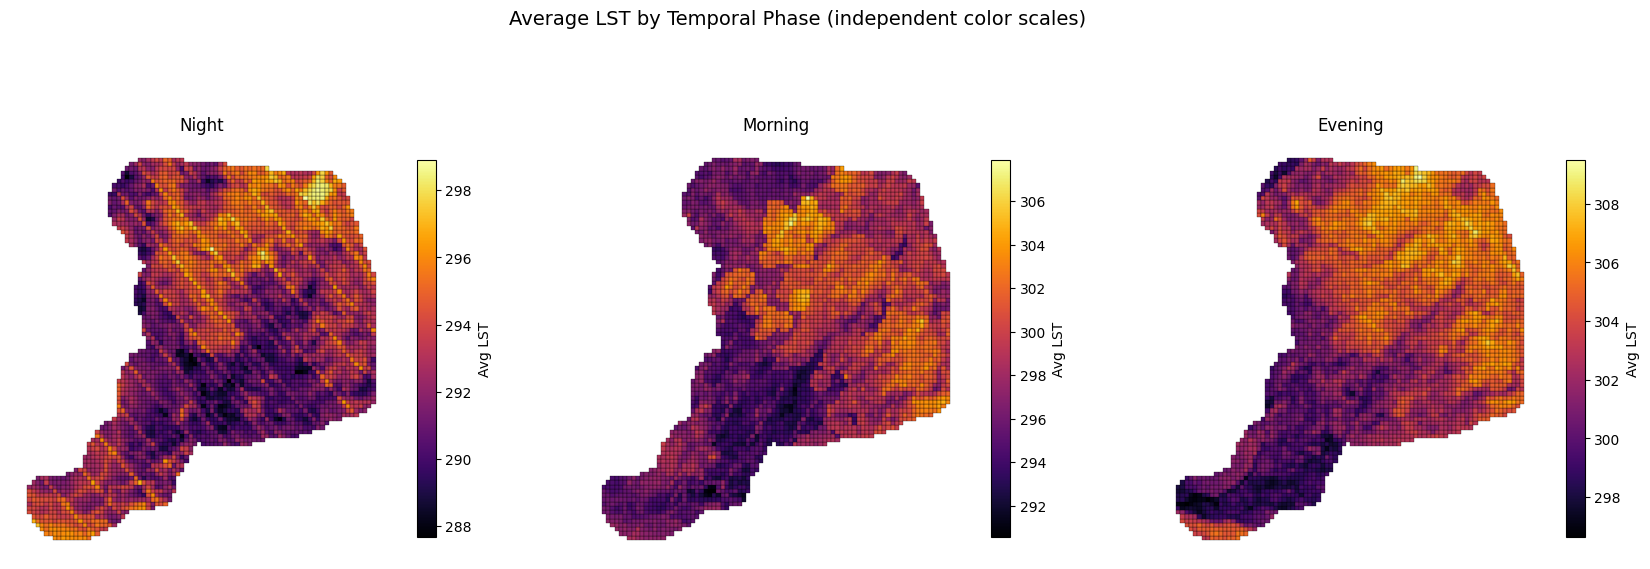

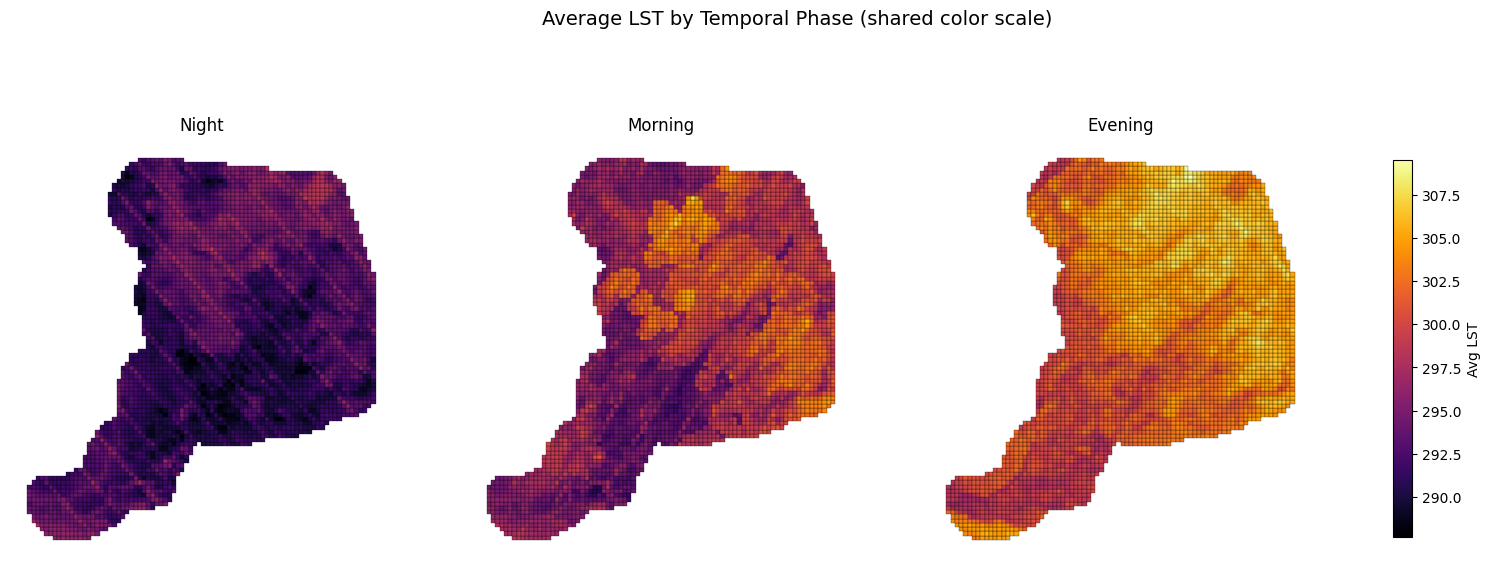

In [137]:
independent_path = plot_phase_row_independent_scales(final_gdf, PHASE_CATEGORIES, FINAL_AVERAGES_DIR)
print(f"Saved -> {independent_path}")

shared_path = plot_phase_row_shared_scale(final_gdf, PHASE_CATEGORIES, FINAL_AVERAGES_DIR)
print(f"Saved -> {shared_path}")